In [1]:
import cv2
import time

img = cv2.imread("images/thermal_image_2.png")
if img is None:
    raise FileNotFoundError("image not found")

start = time.perf_counter()

#gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#gaussian = cv2.GaussianBlur(img, (5, 5), 1.0)
#canny = cv2.Canny(img, 100, 200)
resized = cv2.resize(img, None, fx=0.5, fy=0.5)
end = time.perf_counter()

elapsed_ms = (end - start) * 1000
print(f"Grayscale conversion: {elapsed_ms:.3f} ms")

Grayscale conversion: 8.411 ms


## Compare full-size vs resized processing

In [12]:
from matplotlib import pyplot as plt

def _show_gray_image(img):
    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    plt.axis("off")
    plt.show()

def _show_bgr_image(img):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), vmin=0, vmax=255)
    plt.axis("off")
    plt.show()

original (895, 1192, 3) 9.35 ms


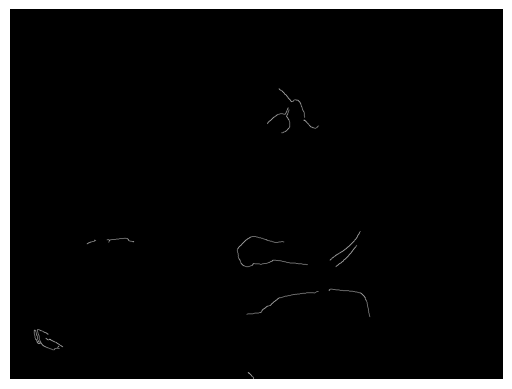

small (448, 596, 3) 2.46 ms


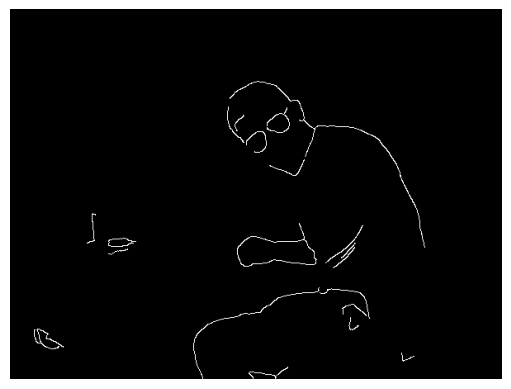

In [3]:
import cv2
import time

img = cv2.imread("images/thermal_image_2.png")
if img is None:
    raise FileNotFoundError("image not found")

small = cv2.resize(img, None, fx=0.5, fy=0.5)

def process(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 100, 200)
    return edges

for name, image in [("original", img), ("small", small)]:
    start = time.perf_counter()
    result = process(image)
    end = time.perf_counter()

    print(name, image.shape, f"{(end - start) * 1000:.2f} ms")
    _show_gray_image(result)

## Color vs Grayscale processing

In [7]:
#processing one channel is usually faster than processing three channels

import cv2
import time

img = cv2.imread("images/thermal_image_2.png")
if img is None:
    raise FileNotFoundError("image not found")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

start = time.perf_counter()
blur_color = cv2.GaussianBlur(img, (9, 9), 0)
end = time.perf_counter()
print(f"Color blur: {(end - start) * 1000:.2f} ms")

start = time.perf_counter()
blur_gray = cv2.GaussianBlur(gray, (9, 9), 0)
end = time.perf_counter()
print(f"Grayscale blur: {(end - start) * 1000:.2f} ms")

Color blur: 2.55 ms
Grayscale blur: 2.73 ms


## Use ROI instead of full image

* detecting objects in a known area
* checking a machine part
* reading a label region
* monitoring a lane/zone

In [8]:
import cv2
import time

img = cv2.imread("images/thermal_image_2.png")
if img is None:
    raise FileNotFoundError("image not found")

h, w = img.shape[:2]

# Example: center ROI
x1 = w // 4
x2 = 3 * w // 4
y1 = h // 4
y2 = 3 * h // 4

roi = img[y1:y2, x1:x2]

def process(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 100, 200)
    return edges

start = time.perf_counter()
full_result = process(img)
end = time.perf_counter()
print(f"Full image: {(end - start) * 1000:.2f} ms")

start = time.perf_counter()
roi_result = process(roi)
end = time.perf_counter()
print(f"ROI only: {(end - start) * 1000:.2f} ms")

Full image: 14.21 ms
ROI only: 3.30 ms


## Compare different blur kernel sizes

Use the smallest kernel that gives acceptable results.

In [9]:
import cv2
import time

img = cv2.imread("images/thermal_image_2.png")
if img is None:
    raise FileNotFoundError("image not found")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

for k in [3, 5, 9, 15, 25, 51]:
    start = time.perf_counter()
    blurred = cv2.GaussianBlur(gray, (k, k), 0)
    end = time.perf_counter()

    print(f"GaussianBlur {k}x{k}: {(end - start) * 1000:.2f} ms")

GaussianBlur 3x3: 0.79 ms
GaussianBlur 5x5: 1.53 ms
GaussianBlur 9x9: 2.17 ms
GaussianBlur 15x15: 4.23 ms
GaussianBlur 25x25: 6.47 ms
GaussianBlur 51x51: 13.53 ms


## Compare algorithms that solve similar problems



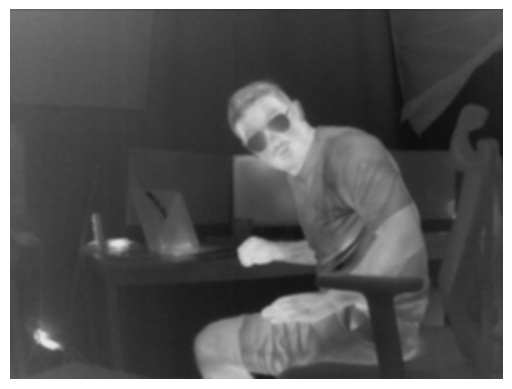

blur: 2.56 ms


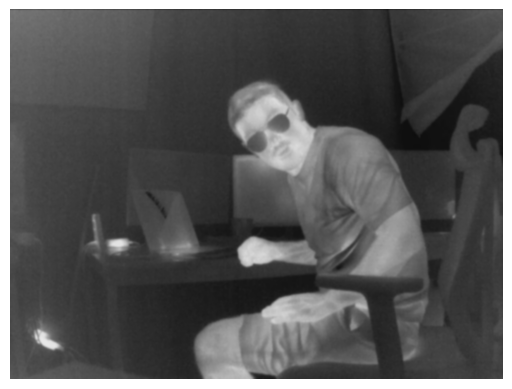

gaussian: 2.67 ms


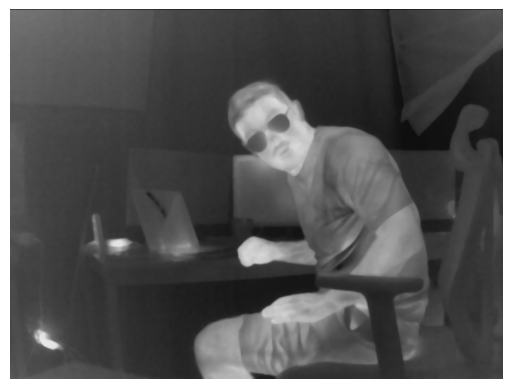

median: 96.46 ms


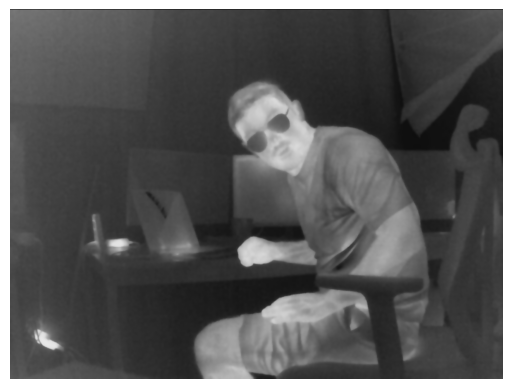

bilateral: 18.00 ms


In [14]:
import cv2
import time

img = cv2.imread("images/thermal_image_2.png")
if img is None:
    raise FileNotFoundError("image not found")

tests = {
    "blur": lambda x: cv2.blur(x, (9, 9)),
    "gaussian": lambda x: cv2.GaussianBlur(x, (9, 9), 0),
    "median": lambda x: cv2.medianBlur(x, 9),
    "bilateral": lambda x: cv2.bilateralFilter(x, 9, 75, 75),
}

for name, func in tests.items():
    start = time.perf_counter()
    result = func(img)
    end = time.perf_counter()
    _show_bgr_image(result)

    print(f"{name}: {(end - start) * 1000:.2f} ms")

## Process every N frames
processing every N frames reduces CPU cost but may miss fast changes

In [16]:
import cv2

cap = cv2.VideoCapture("videos/person_thermal.mkv")

if not cap.isOpened():
    raise RuntimeError("Could not open video")

fps = cap.get(cv2.CAP_PROP_FPS)
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

if fps < 30:
    fps = 30

save_path = "outputs/videos/"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer =  cv2.VideoWriter(save_path + "skiping_frames.mp4", fourcc, fps, (width, height), isColor=False)

frame_index = 0
last_edges = None

process_every = 3

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_index += 1

    if frame_index % process_every == 0:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        last_edges = cv2.Canny(gray, 100, 200)

    cv2.putText(frame, f"Processing every {process_every} frames",
                (20, 40), cv2.FONT_HERSHEY_SIMPLEX,
                0.8, (0, 255, 0), 2)

    if last_edges is not None:
        writer.write(last_edges)

cap.release()
writer.release()

## Compare original vs optimized pipeline

In [17]:
def slow_pipeline(frame):
    blur = cv2.bilateralFilter(frame, 15, 100, 100)
    gray = cv2.cvtColor(blur, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    return edges

def fast_pipeline(frame):
    small = cv2.resize(frame, None, fx=0.5, fy=0.5)
    gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)
    return edges

In [ ]:
import cv2
import time

img = cv2.imread("images/thermal_image_2.png")
if img is None:
    raise FileNotFoundError("image not found")

for name, func in [("slow", slow_pipeline), ("fast", fast_pipeline)]:
    start = time.perf_counter()

    # here we can process several times the same image to calculate processing time in ms/frame
    for _ in range(50):
        result = func(img)

    end = time.perf_counter()

    avg_ms = ((end - start) / 50) * 1000
    print(f"{name}: {avg_ms:.2f} ms/frame")

slow: 39.99 ms/frame
fast: 1.18 ms/frame


## Check OpenCV build information

In [ ]:
import cv2

print(cv2.getBuildInformation())